<a href="https://colab.research.google.com/github/hasinikondle/DataScience_Task/blob/main/Linear_Regression_Task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Taxi Price prediction

In [359]:

# import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error

**Data Preparation**

In [360]:
# loading the data
df = pd.read_csv("taxi_trip_pricing.csv")

In [361]:
# display first 5 rows
df.head()

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.35,Morning,Weekday,3.0,Low,Clear,3.56,0.80,0.32,53.82,36.2624
1,47.59,Afternoon,Weekday,1.0,High,Clear,NaN,0.62,0.43,40.57,NaN
2,36.87,Evening,Weekend,1.0,High,Clear,2.70,1.21,0.15,37.27,52.9032
3,30.33,Evening,Weekday,4.0,Low,NaN,3.48,0.51,0.15,116.81,36.4698
4,NaN,Evening,Weekday,3.0,High,Clear,2.93,0.63,0.32,22.64,15.6180


In [362]:
# getting the information of the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trip_Distance_km       950 non-null    float64
 1   Time_of_Day            950 non-null    object 
 2   Day_of_Week            950 non-null    object 
 3   Passenger_Count        950 non-null    float64
 4   Traffic_Conditions     950 non-null    object 
 5   Weather                950 non-null    object 
 6   Base_Fare              950 non-null    float64
 7   Per_Km_Rate            950 non-null    float64
 8   Per_Minute_Rate        950 non-null    float64
 9   Trip_Duration_Minutes  950 non-null    float64
 10  Trip_Price             951 non-null    float64
dtypes: float64(7), object(4)
memory usage: 86.1+ KB


# EDA

**Data Cleaning**

In [363]:
# Finding null values
df.isnull().sum()

,0
Trip_Distance_km,50
Time_of_Day,50
Day_of_Week,50
Passenger_Count,50
Traffic_Conditions,50
Weather,50
Base_Fare,50
Per_Km_Rate,50
Per_Minute_Rate,50
Trip_Duration_Minutes,50


In [364]:
df.shape

(1000, 11)

In [365]:
# dropping duplicates
df.drop_duplicates(inplace = True)

In [366]:
df.shape

(1000, 11)

In [367]:
df.head()

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.35,Morning,Weekday,3.0,Low,Clear,3.56,0.80,0.32,53.82,36.2624
1,47.59,Afternoon,Weekday,1.0,High,Clear,NaN,0.62,0.43,40.57,NaN
2,36.87,Evening,Weekend,1.0,High,Clear,2.70,1.21,0.15,37.27,52.9032
3,30.33,Evening,Weekday,4.0,Low,NaN,3.48,0.51,0.15,116.81,36.4698
4,NaN,Evening,Weekday,3.0,High,Clear,2.93,0.63,0.32,22.64,15.6180


In [368]:
# handling Trip_Distance_km column
mean = df["Trip_Distance_km"].mean()
df["Trip_Distance_km"] = df["Trip_Distance_km"].fillna(mean)
df["Trip_Distance_km"].unique()

array([ 19.35      ,  47.59      ,  36.87      ,  30.33      ,
        27.07054686,   8.64      ,   3.85      ,  43.44      ,
        30.45      ,  35.7       ,  48.53      ,  41.79      ,
        11.4       ,   9.91      ,   9.99      ,  15.91      ,
        26.71      ,  22.17      ,  15.27      ,  30.98      ,
         7.84      , 105.94355004,  18.95      ,  23.35      ,
        39.47      ,  10.78      , 138.09832791,  30.03      ,
         3.28      ,  30.77      ,   9.36      ,   4.19      ,
        47.5       ,  48.32      ,  40.61      ,  15.93      ,
         5.79      ,  34.53      ,  22.57      ,   6.98      ,
        25.26      ,   2.69      ,  45.56      ,  13.68      ,
        33.46      ,  16.27      ,  26.48      ,  27.79      ,
        10.06      ,  48.51      ,  38.98      ,  47.04      ,
        44.85      ,  30.3       ,  46.17      ,   5.34      ,
        10.6       ,   3.22      ,  16.94      ,  20.05      ,
        14.3       ,  41.61      ,  18.48      , 146.06

In [369]:
# handling Time_of_Day column
mode = df["Time_of_Day"].mode()[0]
df["Time_of_Day"] = df["Time_of_Day"].fillna(mode)
df["Time_of_Day"].unique()


array(['Morning', 'Afternoon', 'Evening', 'Night'], dtype=object)

In [370]:
# handling Day_of_Week column
mode = df["Day_of_Week"].mode()[0]
df["Day_of_Week"] = df["Day_of_Week"].fillna(mode)
df["Day_of_Week"].unique()

array(['Weekday', 'Weekend'], dtype=object)

In [371]:
# handling Passenger_Count column
mode = df["Passenger_Count"].mode()[0]
df["Passenger_Count"] = df["Passenger_Count"].fillna(mode)
df["Passenger_Count"].unique()

array([3., 1., 4., 2.])

In [372]:
# handling Traffic_Conditions column
mode = df["Traffic_Conditions"].mode()[0]
df["Traffic_Conditions"] = df["Traffic_Conditions"].fillna(mode)
df["Traffic_Conditions"].unique()

array(['Low', 'High', 'Medium'], dtype=object)

In [373]:
# handling Weather column
mode = df["Weather"].mode()[0]
df["Weather"] = df["Weather"].fillna(mode)
df["Weather"].unique()

array(['Clear', 'Rain', 'Snow'], dtype=object)

In [374]:
# handling Base_Fare column
mean = df["Base_Fare"].mean()
df["Base_Fare"] = df["Base_Fare"].fillna(mean)
df["Base_Fare"].unique()

array([3.56      , 3.50298947, 2.7       , 3.48      , 2.93      ,
       2.55      , 3.51      , 2.97      , 2.77      , 3.39      ,
       2.4       , 4.78      , 4.6       , 4.12      , 2.32      ,
       4.33      , 4.42      , 4.3       , 2.34      , 3.93      ,
       4.5       , 3.73      , 3.94      , 3.38      , 3.59      ,
       3.92      , 2.24      , 3.31      , 2.88      , 3.64      ,
       4.07      , 4.39      , 2.49      , 2.31      , 2.44      ,
       4.63      , 3.58      , 3.4       , 3.95      , 3.88      ,
       2.23      , 2.15      , 2.41      , 3.16      , 4.83      ,
       3.83      , 4.13      , 4.21      , 2.83      , 3.02      ,
       4.99      , 2.79      , 2.84      , 4.79      , 2.07      ,
       4.09      , 4.18      , 4.51      , 4.92      , 4.93      ,
       2.2       , 4.47      , 2.39      , 4.95      , 4.74      ,
       3.32      , 2.12      , 3.09      , 4.48      , 4.1       ,
       2.17      , 3.28      , 3.41      , 3.08      , 3.43   

In [375]:
# handling Per_Km_Rate column
mean = df["Per_Km_Rate"].mean()
df["Per_Km_Rate"] = df["Per_Km_Rate"].fillna(mean)
df["Per_Km_Rate"].unique()

array([0.8       , 0.62      , 1.21      , 0.51      , 0.63      ,
       1.71      , 1.66      , 1.87      , 1.78      , 1.52      ,
       0.58      , 1.23331579, 1.77      , 1.26      , 0.85      ,
       1.59      , 1.97      , 0.73      , 0.84      , 0.82      ,
       1.69      , 0.78      , 0.6       , 0.54      , 1.75      ,
       1.05      , 1.76      , 1.33      , 1.85      , 1.89      ,
       0.61      , 0.88      , 1.5       , 1.83      , 1.41      ,
       1.95      , 0.9       , 1.25      , 0.72      , 1.16      ,
       1.        , 1.28      , 1.38      , 1.64      , 1.57      ,
       1.63      , 1.93      , 0.86      , 0.99      , 1.37      ,
       1.03      , 1.55      , 1.34      , 1.08      , 1.13      ,
       1.82      , 1.56      , 1.88      , 0.91      , 1.35      ,
       1.91      , 1.61      , 1.12      , 0.57      , 0.79      ,
       1.18      , 0.95      , 1.62      , 0.68      , 1.3       ,
       1.39      , 0.69      , 1.31      , 1.9       , 0.96   

In [376]:
# handling Per_Minute_Rate column
mode = df["Per_Minute_Rate"].mode()[0]
df["Per_Minute_Rate"] = df["Per_Minute_Rate"].fillna(mode)
df["Per_Minute_Rate"].unique()

array([0.32, 0.43, 0.15, 0.48, 0.23, 0.34, 0.47, 0.5 , 0.11, 0.21, 0.2 ,
       0.41, 0.12, 0.25, 0.3 , 0.39, 0.24, 0.35, 0.33, 0.36, 0.13, 0.19,
       0.44, 0.38, 0.42, 0.26, 0.18, 0.17, 0.29, 0.28, 0.31, 0.37, 0.46,
       0.16, 0.4 , 0.1 , 0.27, 0.49, 0.45, 0.14, 0.22])

In [377]:
# handling Trip_Duration_Minutes column
mean = df["Trip_Duration_Minutes"].mean()
df["Trip_Duration_Minutes"] = df["Trip_Duration_Minutes"].fillna(mean)
df["Trip_Duration_Minutes"].unique()


array([ 53.82      ,  40.57      ,  37.27      , 116.81      ,
        22.64      ,  89.33      ,   5.05      ,  62.11811579,
       110.33      ,  26.34      ,  79.94      ,  86.95      ,
        84.12      ,  41.72      ,  34.        , 114.93      ,
       111.18      ,  57.59      ,  57.02      ,  53.8       ,
        23.03      ,  54.04      ,  66.8       ,   7.59      ,
        56.07      ,  94.86      ,  83.21      ,  78.04      ,
       109.6       ,   7.07      ,  69.06      ,  95.55      ,
        67.25      ,  42.25      ,  20.67      , 107.07      ,
        59.14      , 105.98      ,  72.37      ,  82.53      ,
        97.49      ,  80.8       ,  50.78      ,  64.07      ,
        97.35      ,  47.97      ,  49.63      ,  16.        ,
       110.18      ,  15.47      ,  79.54      ,  52.52      ,
        51.65      ,  83.15      ,  12.72      ,  73.28      ,
        93.78      , 100.24      ,  24.61      , 108.2       ,
       106.41      ,  60.81      ,  67.33      , 110.69

In [378]:
# handling Trip_Price column
df["Trip_Price_Calculated"] = (
    df["Base_Fare"] +
    (df["Trip_Distance_km"] * df["Per_Km_Rate"]) +
    (df["Trip_Duration_Minutes"] * df["Per_Minute_Rate"])
)

In [379]:
df["Trip_Price"] = df["Trip_Price"].fillna(df["Trip_Price_Calculated"])

In [380]:
df["Trip_Price"].unique()

array([ 36.2624    ,  50.45388947,  52.9032    ,  36.4698    ,
        15.618     ,  60.2028    ,  11.2645    , 101.1216    ,
        94.4832    ,  75.5657    ,  14.892     , 104.60281526,
        88.1328    ,  36.118     ,  28.9914    ,  27.4415    ,
        56.716     ,  69.0049    ,  69.6268    ,  27.3543    ,
        44.7782    ,  26.2988    , 201.86950919,  39.2366    ,
        33.632     ,  83.6965    ,  28.2443    , 280.87730155,
        64.7971    ,  24.2608    ,  58.8121    ,  20.7765    ,
        25.1105    ,  57.28      ,  61.5552    ,  54.1018    ,
        35.0164    ,  40.9225    ,  60.0471    ,  62.7785    ,
        20.791     ,  57.0482    ,  42.9921    ,  85.884     ,
        29.4758    ,  30.9982    ,  64.0553    ,  44.844     ,
        44.1197    ,  20.1596    , 104.1764    ,  57.0766    ,
        98.3796    ,  41.9343    ,  72.2695    ,  99.8989    ,
        10.2366    ,  32.342     ,  37.1504    ,  78.715     ,
        29.8609    ,  59.181     ,  47.3148    ,  69.65

Do some visualizations to understand distribution of data

<Axes: xlabel='Time_of_Day', ylabel='Count'>

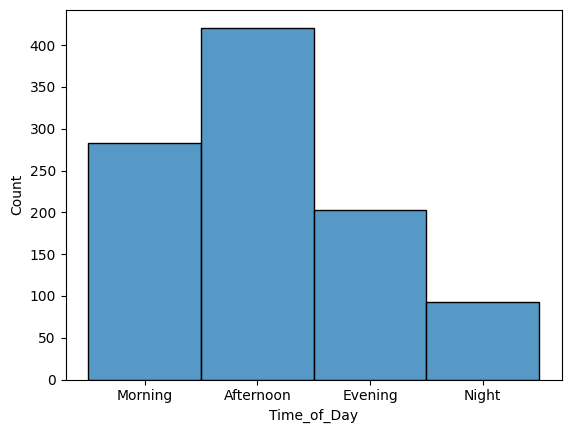

In [381]:
sns.histplot(x="Time_of_Day",data=df)

In [382]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

for col in df.columns:
    if df[col].dtype == object:
        df[col] = encoder.fit_transform(df[col])

<Axes: >

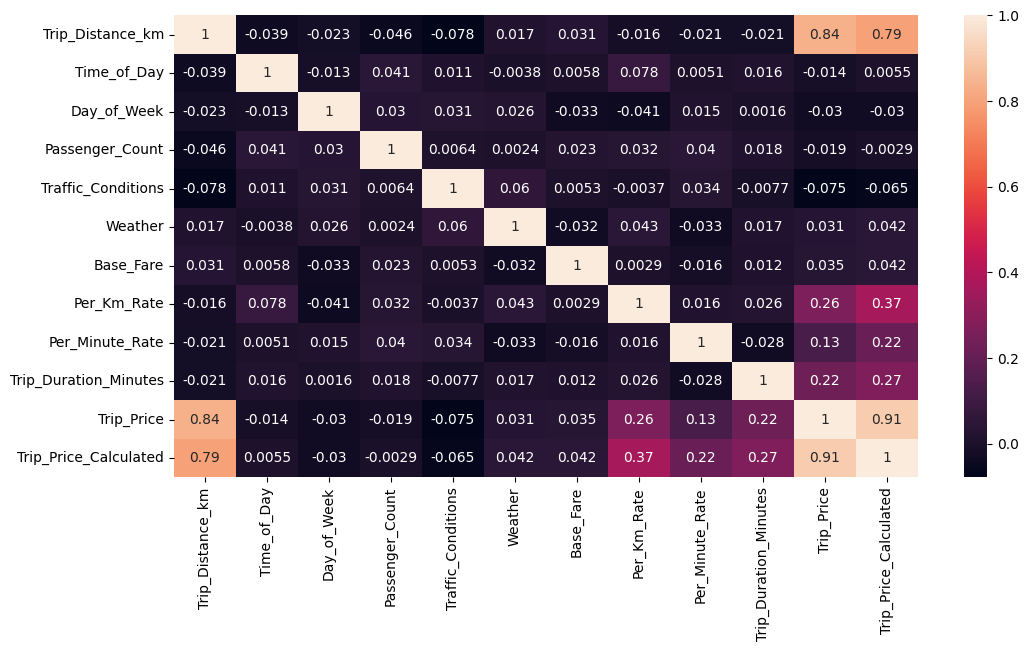

In [383]:
data = df.corr()
plt.figure(figsize=(12,6))
sns.heatmap(data,annot=True)

# Model Training

In [384]:
# divide the data into input and ouput
X = df.drop("Trip_Price",axis=1) #drop output and make X for inputs
y = df["Trip_Price"] #assign output y= output col


In [385]:
# ML rules --> 100% --> 70%(training) , 30%(testing)
# split data into training and testing data
Xtrain,Xtest,ytrain,ytest = train_test_split(X,y,test_size=0.3,random_state=42) #it will always change the values so use random_sate
# Xtest,ytest -- unseened data


**Scaling**

In [386]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
Xtrain = scaler.fit_transform(Xtrain)
Xtest = scaler.transform(Xtest)

In [387]:
# model training
model = LinearRegression()
model.fit(Xtrain,ytrain) #supervise model so we have to pass both input and output  (tuning process)
# 70% of data should be there in training so we have to pass Xtrain,ytrain not Xtest,ytest(bcz these are 30% only)


LinearRegression()

In [388]:
print("Intercept:",model.intercept_)
print("slope:",model.coef_)

Intercept: 57.225600100778806
slope: [ 2.68491812e+01 -2.46163062e-01 -1.25635681e-02 -1.88854035e-01
  1.05692107e-01  3.08101568e-01  5.10905899e-01  6.65189817e+00
  3.26815516e+00  6.22690049e+00  1.10455234e+01]


# Prediction

In [389]:
ypred = model.predict(Xtest)
ypred

array([ 7.83626282e+01,  8.92288963e+01,  6.34427756e+01,  7.62355970e+01,
        1.25866672e+02,  7.05625196e+01,  2.58475385e+01,  5.25926853e+01,
        2.59380770e+01,  7.80645892e+01,  7.61218800e+01,  1.05582624e+02,
        7.51272400e+01,  2.59410062e+01, -1.18347316e+00,  2.07034359e+00,
        6.86271557e+01,  1.03426900e+01,  2.35977696e+01,  3.48736562e+01,
        7.23960604e+01,  3.75153443e+01, -1.77100157e+01,  3.22229519e+01,
        4.20135976e+01,  8.38518342e+01,  7.00611585e+01,  4.63070650e+01,
        3.33709200e+01,  9.32167374e+01,  8.65641664e+01,  8.59181127e+01,
        9.09778647e+00,  1.06472771e+02,  4.30727326e+01,  1.00081670e+02,
        1.87425500e+01,  5.85630192e+01,  1.96773118e+01,  7.55642673e+01,
        5.13079866e+01,  3.68046030e+01,  5.05912254e+00,  3.72867699e+01,
        1.36486877e+01,  5.92462663e+01,  5.23624224e+01,  4.96690395e+01,
        4.27933228e+01,  5.04780212e+01,  6.44897937e+01,  1.14658898e+01,
        7.93734142e+01,  

In [390]:
print("Metrics: ")
r2 = r2_score(ytest,ypred)
print("R2 : ",r2)
N = df.shape[0]
P = df.shape[1]
adj_r2 = 1 - (((1-r2**2) * (N-1)) / (N-P-1))
print("adj R2 : ",adj_r2)
print("MSE : ",mean_squared_error(ytest,ypred))
print("MAE : ",mean_absolute_error(ytest,ypred))


Metrics: 
R2 :  0.8428259789413732
adj R2 :  0.7068341186906846
MSE :  208.29975617482776
MAE :  9.042688654193405


In [391]:
print("Training Eff: ",model.score(Xtrain,ytrain)) #less than 80% so it is generalized model
print("Testing Eff: ",model.score(Xtest,ytest))

Training Eff:  0.8826999087137538
Testing Eff:  0.8428259789413732
